## Phase 5: Transformers & Attention

In [2]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms
from torch import nn
import os
import pandas as pd
import matplotlib.pyplot as plt
from torchvision.io import read_image

device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {device}")

Using device: mps


## Dataset Preparation

In [ ]:
DATA_DIR = "../Datasets"
AQI_CSV  = os.path.join(DATA_DIR, "delhi_aqi_dataset", "delhi_aqi.csv")
IMG_DIR  = os.path.join(DATA_DIR, "plantvillage_dataset", "segmented")

In [ ]:
# ── Delhi AQI Time-Series Dataset ───────────────────────────────────────────
class AQITimeSeriesDataset(Dataset):
    """
    Sliding-window dataset over Delhi AQI (pm2_5 column).
    Each sample: X = seq_len time-steps, y = value `horizon` steps ahead.
    """
    def __init__(self, csv_path, seq_len=72, horizon=24, col='pm2_5', train_frac=0.7):
        df   = pd.read_csv(csv_path)
        data = torch.tensor(df[col].values, dtype=torch.float32)

        n_train     = int(train_frac * len(data))
        self.mean   = data[:n_train].mean()
        self.std    = data[:n_train].std().clamp(min=1e-8)
        data        = (data - self.mean) / self.std

        self.seq_len   = seq_len
        self.input_dim = seq_len          # for MLP compatibility

        xs, ys = [], []
        for i in range(len(data) - seq_len - horizon):
            xs.append(data[i : i + seq_len])
            ys.append(data[i + seq_len + horizon])

        self.X = torch.stack(xs)   # (N, seq_len)
        self.y = torch.stack(ys)   # (N,)

    def __len__(self):              return len(self.X)
    def __getitem__(self, idx):     return self.X[idx], self.y[idx]

In [ ]:
# ── PlantVillage plain-image Dataset (for CNN) ─────────────────
class PlantVillageDataset(Dataset):
    """Loads images and integer class labels."""
    def __init__(self, root_dir, transform=None):
        self.transform   = transform
        self.image_paths = []
        self.labels      = []

        class_names = sorted([d for d in os.listdir(root_dir)
                               if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {c: i for i, c in enumerate(class_names)}

        for cls in class_names:
            cls_dir = os.path.join(root_dir, cls)
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.image_paths.append(os.path.join(cls_dir, fname))
                    self.labels.append(self.class_to_idx[cls])

    def __len__(self):  return len(self.image_paths)

    def __getitem__(self, idx):
        img = read_image(self.image_paths[idx])[:3].float() / 255.0
        if img.shape[0] == 1:
            img = img.repeat(3, 1, 1)
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(self.labels[idx], dtype=torch.long)

In [6]:
# ── PlantVillage Patch Dataset (for ViT) ────────────────────────────────────
class PatchedPlantVillageDataset(Dataset):
    """
    Slices each 128×128 image into non-overlapping 16×16 patches.
    Each patch is flattened to a 1-D vector of length 3×16×16 = 768.
    Returns (patches, label) where patches has shape (num_patches, 768).
    For a 128×128 image with 16×16 patches: 8×8 = 64 patches.
    """
    def __init__(self, root_dir, transform=None, patch_size=16):
        self.transform   = transform
        self.patch_size  = patch_size
        self.image_paths = []
        self.labels      = []

        class_names = sorted([d for d in os.listdir(root_dir)
                               if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {c: i for i, c in enumerate(class_names)}

        for cls in class_names:
            cls_dir = os.path.join(root_dir, cls)
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.image_paths.append(os.path.join(cls_dir, fname))
                    self.labels.append(self.class_to_idx[cls])

    def __len__(self):  return len(self.image_paths)

    def __getitem__(self, idx):
        img = read_image(self.image_paths[idx])[:3].float() / 255.0
        if img.shape[0] == 1:
            img = img.repeat(3, 1, 1)
        if self.transform:
            img = self.transform(img)

        p   = self.patch_size
        H, W = img.shape[1], img.shape[2]
        patches = []
        for row in range(0, H, p):
            for col in range(0, W, p):
                patch = img[:, row:row+p, col:col+p]
                if patch.shape[1] == p and patch.shape[2] == p:
                    patches.append(patch.flatten())   # shape: (3*p*p,)

        patches = torch.stack(patches)               # shape: (num_patches, 3*p*p)
        label   = torch.tensor(self.labels[idx], dtype=torch.long)
        return patches, label

In [ ]:
resize_128 = transforms.Resize((128, 128))

aqi_dataset          = AQITimeSeriesDataset(AQI_CSV, seq_len=72, horizon=24)
plantvillage_plain   = PlantVillageDataset(IMG_DIR, transform=resize_128)
plantvillage_patched = PatchedPlantVillageDataset(IMG_DIR, transform=resize_128)

print(f"AQI dataset size      : {len(aqi_dataset)}")
print(f"PlantVillage plain    : {len(plantvillage_plain)}")
print(f"PlantVillage patched  : {len(plantvillage_patched)}")

AQI dataset size      : 18680
PlantVillage plain    : 54306
PlantVillage patched  : 54306


In [ ]:
def count_params(model):
    """Count trainable parameters."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def compute_accuracy(dataloader, model):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y   = X.to(device), y.to(device)
            logits = model(X)
            correct += (logits.argmax(dim=1) == y).sum().item()
            total   += len(y)
    return correct / total

def train_model(train_loader, val_loader, model, loss_fn, optimizer,
                num_epochs=100, patience=10):
    best_val_loss    = float('inf')
    no_improve_count = 0
    best_state       = None

    for epoch in range(num_epochs):
        # ── Training ────────────────────────────────────────────────────
        model.train()
        running_loss = 0.0
        for X, y in train_loader:
            X, y   = X.to(device), y.float().to(device)
            pred   = model(X)
            loss   = loss_fn(pred, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        train_loss = running_loss / len(train_loader)

        # ── Validation ──────────────────────────────────────────────────
        model.eval()
        val_loss_sum = 0.0
        with torch.no_grad():
            for X, y in val_loader:
                X, y        = X.to(device), y.float().to(device)
                pred        = model(X)
                val_loss_sum += loss_fn(pred, y).item()
        val_loss = val_loss_sum / len(val_loader)

        if epoch % 10 == 0:
            print(f"Epoch {epoch:3d}: train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")

        # ── Early stopping ──────────────────────────────────────────────
        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            no_improve_count = 0
            best_state       = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            no_improve_count += 1
            if no_improve_count >= patience:
                print(f"Early stopping at epoch {epoch}.  Best val_loss={best_val_loss:.4f}")
                model.load_state_dict(best_state)
                return

def evaluate_mse(dataloader, model, loss_fn):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for X, y in dataloader:
            X, y       = X.to(device), y.float().to(device)
            pred       = model(X)
            total_loss += loss_fn(pred, y).item()
    mse = total_loss / len(dataloader)
    print(f"Test MSE: {mse:.4f}")
    return mse

---
## Problem 5.13 — Scaled Dot-Product Attention

In [11]:
class ScaledDotProductAttentionModel(nn.Module):
    """
    Single-head Transformer Encoder for time-series regression.
    Steps:
      1. Project each time-step from input_dim → model_dim.
      2. Compute Q, K, V projections.
      3. Scaled dot-product attention.
      4. Take the last position's output and project to output_dim.
    """
    def __init__(self, input_dim, model_dim, output_dim):
        super().__init__()
        self.input_proj   = nn.Linear(input_dim, model_dim)
        self.query_proj   = nn.Linear(model_dim, model_dim)
        self.key_proj     = nn.Linear(model_dim, model_dim)
        self.value_proj   = nn.Linear(model_dim, model_dim)
        self.output_proj  = nn.Linear(model_dim, output_dim)
        self.scale_factor = model_dim ** 0.5

    def forward(self, x):
        # x: (batch, seq_len)  →  unsqueeze to (batch, seq_len, 1)
        if x.dim() == 2:
            x = x.unsqueeze(-1)

        h = self.input_proj(x)                                      # (B, T, D)
        Q = self.query_proj(h)
        K = self.key_proj(h)
        V = self.value_proj(h)

        attn_scores   = torch.matmul(Q, K.transpose(-2, -1)) / self.scale_factor
        attn_weights  = torch.softmax(attn_scores, dim=-1)         # (B, T, T)
        context       = torch.matmul(attn_weights, V)              # (B, T, D)

        out = self.output_proj(context[:, -1, :])                  # last token
        return out.squeeze(1)                                       # (B,)

    @torch.no_grad()
    def get_attention_weights(self, x):
        """Return the (T, T) attention weight matrix for a single sample."""
        if x.dim() == 2:
            x = x.unsqueeze(-1)
        h = self.input_proj(x)
        Q = self.query_proj(h)
        K = self.key_proj(h)
        scores  = torch.matmul(Q, K.transpose(-2, -1)) / self.scale_factor
        weights = torch.softmax(scores, dim=-1)
        return weights.cpu().numpy()

In [12]:
# ── Chronological splits for AQI ────────────────────────────────────────────
N         = len(aqi_dataset)
train_end = int(0.70 * N)
val_end   = int(0.85 * N)

aqi_train = Subset(aqi_dataset, range(0, train_end))
aqi_val   = Subset(aqi_dataset, range(train_end, val_end))
aqi_test  = Subset(aqi_dataset, range(val_end, N))

aqi_train_loader = DataLoader(aqi_train, batch_size=32, shuffle=False)
aqi_val_loader   = DataLoader(aqi_val,   batch_size=32, shuffle=False)
aqi_test_loader  = DataLoader(aqi_test,  batch_size=32, shuffle=False)

print(f"Train: {len(aqi_train)}  Val: {len(aqi_val)}  Test: {len(aqi_test)}")

Train: 13076  Val: 2802  Test: 2802


In [13]:
torch.manual_seed(42)

attn_model_513 = ScaledDotProductAttentionModel(
    input_dim=1, model_dim=128, output_dim=1
).to(device)

optimizer_513 = torch.optim.Adam(attn_model_513.parameters(), lr=1e-3)
mse_loss      = nn.MSELoss()

train_model(aqi_train_loader, aqi_val_loader, attn_model_513,
            mse_loss, optimizer_513, num_epochs=100, patience=10)
evaluate_mse(aqi_test_loader, attn_model_513, mse_loss)

Epoch   0: train_loss=0.8490  val_loss=0.2468
Epoch  10: train_loss=0.7368  val_loss=0.2940
Early stopping at epoch 10.  Best val_loss=0.2468
Test MSE: 1.1800


1.1800256103531204

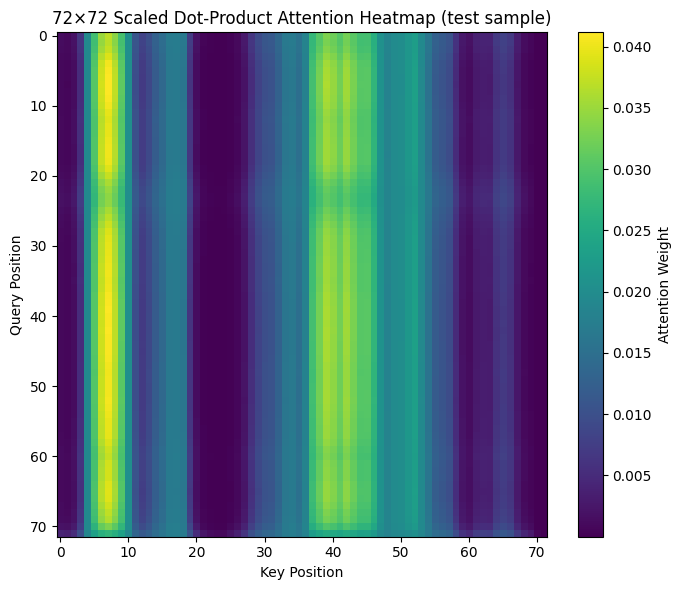

In [14]:
# ── Extract and plot the 72×72 attention weight heatmap ─────────────────────
sample_x, _ = aqi_test[0]
sample_x    = sample_x.to(device).unsqueeze(0)   # (1, 72)

attn_map = attn_model_513.get_attention_weights(sample_x)  # (1, 72, 72)

plt.figure(figsize=(7, 6))
plt.imshow(attn_map[0], cmap="viridis", aspect="auto")
plt.colorbar(label="Attention Weight")
plt.xlabel("Key Position")
plt.ylabel("Query Position")
plt.title("72×72 Scaled Dot-Product Attention Heatmap (test sample)")
plt.tight_layout()
plt.savefig("attention_heatmap_513.png", dpi=150)
plt.show()

---
## Problem 5.14 — The Necessity of Positional Encoding

In [15]:
class TransformerWithPosEncoding(nn.Module):
    """
    Same single-head Transformer as above, but with sinusoidal positional
    encodings added to the projected input before attention.
    """
    def __init__(self, input_dim, model_dim, output_dim, max_seq_len=72):
        super().__init__()
        self.input_proj   = nn.Linear(input_dim, model_dim)
        self.query_proj   = nn.Linear(model_dim, model_dim)
        self.key_proj     = nn.Linear(model_dim, model_dim)
        self.value_proj   = nn.Linear(model_dim, model_dim)
        self.output_proj  = nn.Linear(model_dim, output_dim)
        self.scale_factor = model_dim ** 0.5

        # Pre-compute and register sinusoidal positional encodings (non-trainable)
        pe       = torch.zeros(max_seq_len, model_dim)             # (T, D)
        positions = torch.arange(0, max_seq_len).unsqueeze(1).float()
        freq_div  = torch.exp(
            torch.arange(0, model_dim, 2).float() * (-np.log(10000.0) / model_dim)
        )
        pe[:, 0::2] = torch.sin(positions * freq_div)
        pe[:, 1::2] = torch.cos(positions * freq_div)
        self.register_buffer("pos_encoding", pe.unsqueeze(0))      # (1, T, D)

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(-1)

        h = self.input_proj(x)
        T = h.size(1)
        h = h + self.pos_encoding[:, :T, :]                       # add PE

        Q = self.query_proj(h)
        K = self.key_proj(h)
        V = self.value_proj(h)

        attn_scores  = torch.matmul(Q, K.transpose(-2, -1)) / self.scale_factor
        attn_weights = torch.softmax(attn_scores, dim=-1)
        context      = torch.matmul(attn_weights, V)

        out = self.output_proj(context[:, -1, :])
        return out.squeeze(1)

In [ ]:
torch.manual_seed(42)

# ── Model without positional encoding ────────
model_no_pe  = ScaledDotProductAttentionModel(input_dim=1, model_dim=64, output_dim=1).to(device)
# ── Model with sinusoidal positional encoding ────────────────────────────────
model_with_pe = TransformerWithPosEncoding(input_dim=1, model_dim=64, output_dim=1).to(device)

opt_no_pe   = torch.optim.Adam(model_no_pe.parameters(),   lr=1e-2)
opt_with_pe = torch.optim.Adam(model_with_pe.parameters(), lr=1e-2)

print("=== Transformer WITHOUT positional encoding ===")
train_model(aqi_train_loader, aqi_val_loader, model_no_pe,
            mse_loss, opt_no_pe, num_epochs=100, patience=10)
no_pe_test_mse = evaluate_mse(aqi_test_loader, model_no_pe, mse_loss)

print("\n=== Transformer WITH sinusoidal positional encoding ===")
train_model(aqi_train_loader, aqi_val_loader, model_with_pe,
            mse_loss, opt_with_pe, num_epochs=100, patience=10)
with_pe_test_mse = evaluate_mse(aqi_test_loader, model_with_pe, mse_loss)

print(f"\nTest MSE (no PE): {no_pe_test_mse:.4f}  |  Test MSE (with PE): {with_pe_test_mse:.4f}")

=== Transformer WITHOUT positional encoding ===
Epoch   0: train_loss=0.9337  val_loss=0.2686
Epoch  10: train_loss=0.8788  val_loss=0.2884
Early stopping at epoch 15.  Best val_loss=0.2517
Test MSE: 1.3632

=== Transformer WITH sinusoidal positional encoding ===
Epoch   0: train_loss=0.8075  val_loss=0.2362
Epoch  10: train_loss=0.6827  val_loss=0.2487
Early stopping at epoch 19.  Best val_loss=0.2342
Test MSE: 1.0986

Test MSE (no PE): 1.3632  |  Test MSE (with PE): 1.0986


---
## Problem 5.15 — Vision Transformer (ViT)

In [1]:
# input_dim = 768 (patch dimension), model_dim = 64, output_dim = 38 classes

NUM_CLASSES = 38   # PlantVillage has 38 disease/healthy classes

vit_model = ScaledDotProductAttentionModel(
    input_dim=768, model_dim=64, output_dim=NUM_CLASSES
).to(device)

print(f"ViT parameter count: {count_params(vit_model):,}")

NameError: name 'ScaledDotProductAttentionModel' is not defined

In [ ]:
import torchvision
np.random.seed(42)
torch.manual_seed(42)

M      = len(plantvillage_patched)
idx    = np.random.permutation(M)

tr_idx  = idx[: int(0.70 * M)]
va_idx  = idx[int(0.70 * M) : int(0.85 * M)]
te_idx  = idx[int(0.85 * M) :]

vit_train   = Subset(plantvillage_patched, tr_idx)
vit_val     = Subset(plantvillage_patched, va_idx)
vit_test    = Subset(plantvillage_patched, te_idx)


cnn_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
cnn_full = torchvision.datasets.ImageFolder(root=IMG_DIR, transform=cnn_transform)
cnn_test = Subset(cnn_full, te_idx)

vit_train_loader = DataLoader(vit_train, batch_size=32, shuffle=False)
vit_val_loader   = DataLoader(vit_val,   batch_size=32, shuffle=False)
vit_test_loader  = DataLoader(vit_test,  batch_size=32, shuffle=False)
cnn_test_loader  = DataLoader(cnn_test,  batch_size=32, shuffle=False)

print(f"ViT train/val/test: {len(vit_train)} / {len(vit_val)} / {len(vit_test)}")

ViT train/val/test: 38014 / 8146 / 8146


In [ ]:
# ── Train ViT for classification ─────────────────────────────────────────────
cross_entropy = nn.CrossEntropyLoss()
opt_vit       = torch.optim.Adam(vit_model.parameters(), lr=1e-3)

def train_classifier(train_loader, val_loader, model, loss_fn, optimizer,
                     num_epochs=20, patience=10, save_path=None):
    best_val_loss    = float('inf')
    no_improve_count = 0
    best_state       = None

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for X, y in train_loader:
            X, y   = X.to(device), y.to(device)
            logits = model(X)
            loss   = loss_fn(logits, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        train_loss = running_loss / len(train_loader)

        model.eval()
        val_loss_sum = 0.0
        with torch.no_grad():
            for X, y in val_loader:
                X, y        = X.to(device), y.to(device)
                val_loss_sum += loss_fn(model(X), y).item()
        val_loss = val_loss_sum / len(val_loader)

        if epoch % 10 == 0:
            print(f"Epoch {epoch:3d}: train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            no_improve_count = 0
            best_state       = {k: v.clone() for k, v in model.state_dict().items()}
            if save_path:
                torch.save(best_state, save_path)
                print(f"  ✔ Saved best model to {save_path}  (val_loss={best_val_loss:.4f})")
        else:
            no_improve_count += 1
            if no_improve_count >= patience:
                print(f"Early stopping at epoch {epoch}.  Best val_loss={best_val_loss:.4f}")
                model.load_state_dict(best_state)
                return

train_classifier(vit_train_loader, vit_val_loader, vit_model,
                 cross_entropy, opt_vit, num_epochs=20, patience=10,
                 save_path='best_model_vit.pt')

Epoch   0: train_loss=2.7389  val_loss=2.4849
  ✔ Saved best model to best_model_vit.pt  (val_loss=2.4849)
  ✔ Saved best model to best_model_vit.pt  (val_loss=2.3570)
  ✔ Saved best model to best_model_vit.pt  (val_loss=2.3132)
  ✔ Saved best model to best_model_vit.pt  (val_loss=2.2898)
  ✔ Saved best model to best_model_vit.pt  (val_loss=2.2777)
  ✔ Saved best model to best_model_vit.pt  (val_loss=2.2739)
  ✔ Saved best model to best_model_vit.pt  (val_loss=2.2628)
  ✔ Saved best model to best_model_vit.pt  (val_loss=2.2529)
  ✔ Saved best model to best_model_vit.pt  (val_loss=2.2471)
  ✔ Saved best model to best_model_vit.pt  (val_loss=2.2407)
Epoch  10: train_loss=2.2408  val_loss=2.2282
  ✔ Saved best model to best_model_vit.pt  (val_loss=2.2282)
  ✔ Saved best model to best_model_vit.pt  (val_loss=2.1810)
  ✔ Saved best model to best_model_vit.pt  (val_loss=2.1387)
  ✔ Saved best model to best_model_vit.pt  (val_loss=2.0846)
  ✔ Saved best model to best_model_vit.pt  (val_loss=2

In [ ]:
CNN_DATA_DIR = '../Datasets/plantvillage_dataset/color'
cnn_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
cnn_color_full = torchvision.datasets.ImageFolder(root=CNN_DATA_DIR, transform=cnn_transform)

Nc      = len(cnn_color_full)
n_train = int(0.70 * Nc)
n_val   = int(0.15 * Nc)
n_test  = Nc - n_train - n_val
gen_cnn = torch.Generator().manual_seed(42)
_, _, cnn_test_split = torch.utils.data.random_split(
    cnn_color_full, [n_train, n_val, n_test], generator=gen_cnn
)
cnn_test_loader_color = DataLoader(cnn_test_split, batch_size=32, shuffle=False)
print(f"CNN color test set size: {len(cnn_test_split)}")

class PlantCNN(nn.Module):
    """3-block CNN: Conv2d + BatchNorm2d + ReLU + MaxPool2d."""

    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 8,  kernel_size=3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(8)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(16)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.conv3 = nn.Conv2d(16, 32, kernel_size=3, padding=1, bias=False)
        self.bn3   = nn.BatchNorm2d(32)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.relu    = nn.ReLU(inplace=True)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32 * 16 * 16, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu(self.bn3(self.conv3(x))))
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        return self.fc2(x)

cnn_model = PlantCNN(num_classes=NUM_CLASSES).to(device)
cnn_weights_path = 'best_model_q2_4.pt'
cnn_model.load_state_dict(torch.load(cnn_weights_path, map_location=device))
print(f'Loaded CNN weights from {cnn_weights_path}')

CNN color test set size: 8147
Loaded CNN weights from best_model_q2_4.pt


In [ ]:
# ── Parameter efficiency comparison ─────────────────────────────────────────
vit_accuracy = compute_accuracy(vit_test_loader, vit_model)
cnn_accuracy = compute_accuracy(cnn_test_loader_color, cnn_model)

vit_params   = count_params(vit_model)
cnn_params   = count_params(cnn_model)

vit_efficiency = vit_accuracy / vit_params if vit_params > 0 else 0
cnn_efficiency = cnn_accuracy / cnn_params if cnn_params > 0 else 0

print(f"{'Model':<20} {'Accuracy':>10} {'# Params':>12} {'Acc/Param':>14}")
print("-" * 58)
print(f"{'CNN (Phase 2)':<20} {cnn_accuracy*100:>9.2f}% {cnn_params:>12,} {cnn_efficiency:>14.2e}")
print(f"{'ViT (this)':<20} {vit_accuracy*100:>9.2f}% {vit_params:>12,} {vit_efficiency:>14.2e}")

Model                  Accuracy     # Params      Acc/Param
----------------------------------------------------------
CNN (Phase 2)            91.94%    2,113,262       4.35e-07
ViT (this)               43.29%       64,166       6.75e-06
